# CELL 1 - Link Github

In [1]:
!rm -rf /kaggle/working/LITE-Time-Series
!git clone https://github.com/Kiran301103/LITE-Time-Series.git /kaggle/working/LITE-Time-Series
%cd /kaggle/working/LITE-Time-Series
!ls

Cloning into '/kaggle/working/LITE-Time-Series'...
remote: Enumerating objects: 46, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 46 (delta 1), reused 46 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (46/46), 1.19 MiB | 7.06 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/kaggle/working/LITE-Time-Series
changelog.md		 LICENSE	 README_og.md		     src
docs			 main.py	 results.csv
experimentation_results  pyproject.toml  results_ensemble_study.csv
images			 README.md	 results_multivariate.csv


# Cell 2 - List the csv files

In [3]:
import os

for root, dirs, files in os.walk(".", topdown=True):
    for name in files:
        if name.endswith(".csv"):
            print(os.path.join(root, name))

./results_ensemble_study.csv
./results_multivariate.csv
./results.csv
./experimentation_results/fast_subset_baseline.csv
./experimentation_results/batch_128.csv
./experimentation_results/adamw_results.csv
./experimentation_results/batch_32.csv
./experimentation_results/reproduced_results/no_change_reproduced_results_ucr.csv
./experimentation_results/reproduced_results/average_reproduced.csv


# Cell 3 - Plot Code

Files loaded successfully!


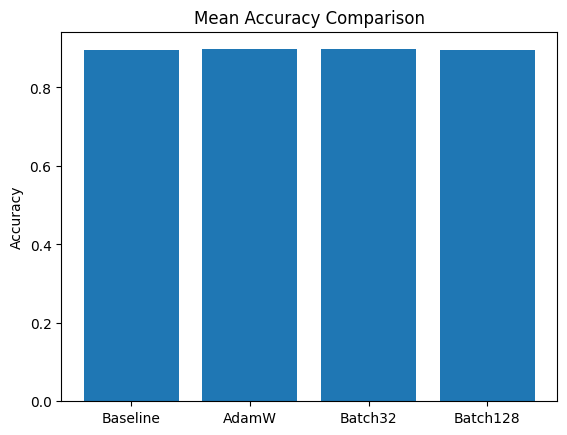

Plot 1 done


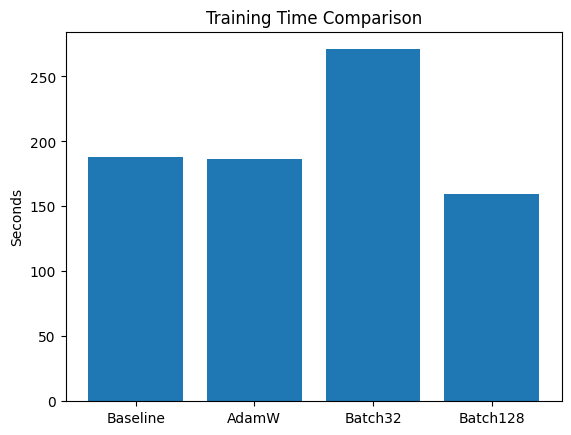

Plot 2 done


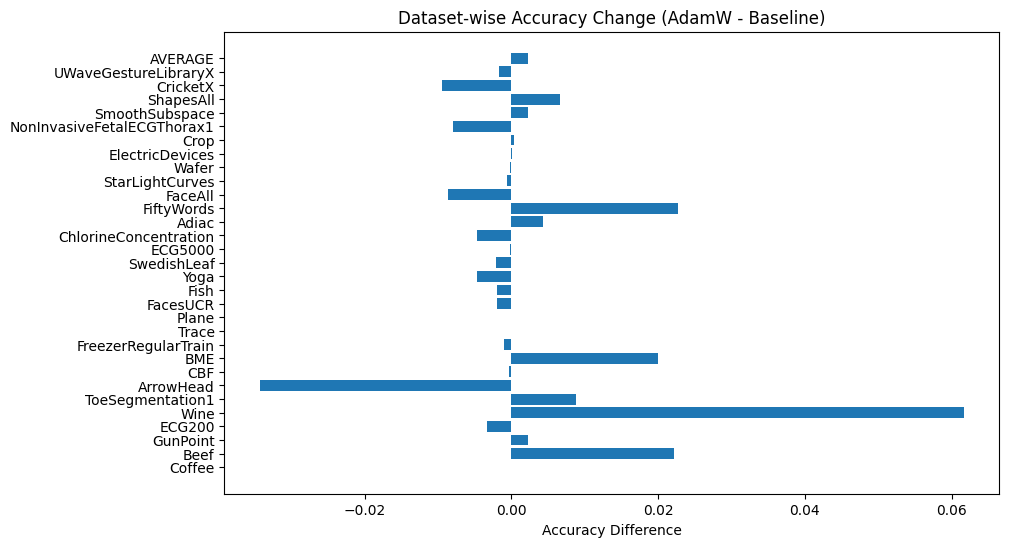

Plot 3 done


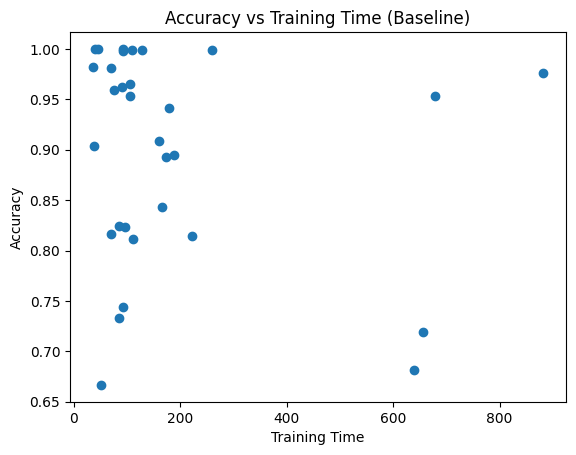

Plot 4 done

All plots generated successfully!


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Create folder
os.makedirs("plots", exist_ok=True)

# Load datasets (correct paths)

baseline = pd.read_csv(
    "./experimentation_results/fast_subset_baseline.csv"
)

adamw = pd.read_csv(
    "./experimentation_results/adamw_results.csv"
)

batch32 = pd.read_csv(
    "./experimentation_results/batch_32.csv"
)

batch128 = pd.read_csv(
    "./experimentation_results/batch_128.csv"
)

print("Files loaded successfully!")

# =========================
# PLOT 1 — Accuracy Comparison
# =========================

means = [
    baseline["LITE-mean"].mean(),
    adamw["LITE-mean"].mean(),
    batch32["LITE-mean"].mean(),
    batch128["LITE-mean"].mean()
]

labels = ["Baseline", "AdamW", "Batch32", "Batch128"]

plt.figure()

plt.bar(labels, means)

plt.title("Mean Accuracy Comparison")
plt.ylabel("Accuracy")

plt.savefig("plots/accuracy_comparison.png")

plt.show()

print("Plot 1 done")


# =========================
# PLOT 2 — Training Time
# =========================

times = [
    baseline["Training Time (s)-mean"].mean(),
    adamw["Training Time (s)-mean"].mean(),
    batch32["Training Time (s)-mean"].mean(),
    batch128["Training Time (s)-mean"].mean()
]

plt.figure()

plt.bar(labels, times)

plt.title("Training Time Comparison")
plt.ylabel("Seconds")

plt.savefig("plots/training_time_comparison.png")

plt.show()

print("Plot 2 done")


# =========================
# PLOT 3 — Dataset Improvement
# =========================

merged = pd.merge(
    baseline[["dataset","LITE-mean"]],
    adamw[["dataset","LITE-mean"]],
    on="dataset",
    suffixes=("_base","_adamw")
)

merged["delta"] = (
    merged["LITE-mean_adamw"]
    - merged["LITE-mean_base"]
)

plt.figure(figsize=(10,6))

plt.barh(
    merged["dataset"],
    merged["delta"]
)

plt.title("Dataset-wise Accuracy Change (AdamW - Baseline)")
plt.xlabel("Accuracy Difference")

plt.savefig("plots/dataset_improvement.png")

plt.show()

print("Plot 3 done")


# =========================
# PLOT 4 — Time vs Accuracy
# =========================

plt.figure()

plt.scatter(
    baseline["Training Time (s)-mean"],
    baseline["LITE-mean"]
)

plt.title("Accuracy vs Training Time (Baseline)")
plt.xlabel("Training Time")
plt.ylabel("Accuracy")

plt.savefig("plots/time_vs_accuracy.png")

plt.show()

print("Plot 4 done")

print("\nAll plots generated successfully!")

# Cell 4 - Results Table

In [6]:
import pandas as pd

# Load datasets

baseline = pd.read_csv(
    "./experimentation_results/fast_subset_baseline.csv"
)

adamw = pd.read_csv(
    "./experimentation_results/adamw_results.csv"
)

batch32 = pd.read_csv(
    "./experimentation_results/batch_32.csv"
)

batch128 = pd.read_csv(
    "./experimentation_results/batch_128.csv"
)

# Create summary table

summary = pd.DataFrame({

    "Experiment": [
        "Baseline (Adam)",
        "AdamW Optimizer",
        "Batch Size 32",
        "Batch Size 128"
    ],

    "Mean Accuracy": [
        baseline["LITE-mean"].mean(),
        adamw["LITE-mean"].mean(),
        batch32["LITE-mean"].mean(),
        batch128["LITE-mean"].mean()
    ],

    "Training Time (s)": [
        baseline["Training Time (s)-mean"].mean(),
        adamw["Training Time (s)-mean"].mean(),
        batch32["Training Time (s)-mean"].mean(),
        batch128["Training Time (s)-mean"].mean()
    ]

})

summary = summary.round(4)

summary.to_csv("results_summary_table.csv", index=False)

print(summary)
print("\nTable saved as results_summary_table.csv")

        Experiment  Mean Accuracy  Training Time (s)
0  Baseline (Adam)         0.8950           187.6927
1  AdamW Optimizer         0.8973           186.4666
2    Batch Size 32         0.8968           270.8580
3   Batch Size 128         0.8943           159.6003

Table saved as results_summary_table.csv


# Cell 5- Comparison table at dataset level

In [7]:
merged = pd.merge(
    baseline[["dataset","LITE-mean"]],
    adamw[["dataset","LITE-mean"]],
    on="dataset",
    suffixes=("_baseline","_adamw")
)

merged["Improvement"] = (
    merged["LITE-mean_adamw"]
    - merged["LITE-mean_baseline"]
)

merged = merged.round(4)

merged.to_csv(
    "dataset_level_comparison.csv",
    index=False
)

print(merged.head())
print("\nDataset comparison table saved.")

    dataset  LITE-mean_baseline  LITE-mean_adamw  Improvement
0    Coffee              1.0000           1.0000       0.0000
1      Beef              0.7333           0.7556       0.0222
2  GunPoint              0.9978           1.0000       0.0022
3    ECG200              0.9033           0.9000      -0.0033
4      Wine              0.6667           0.7284       0.0617

Dataset comparison table saved.


# Cell 6 - Win / Loss Statistics

In [8]:
wins = (merged["Improvement"] > 0).sum()
losses = (merged["Improvement"] < 0).sum()
ties = (merged["Improvement"] == 0).sum()

print("AdamW vs Baseline")
print("Wins:", wins)
print("Losses:", losses)
print("Ties:", ties)

AdamW vs Baseline
Wins: 12
Losses: 16
Ties: 3
